In [16]:
import os 
import joblib
import requests
import datetime
import pandas as pd
import yfinance as yf
import missingno as msno
from fredapi import Fred
from datetime import date 
from dotenv import load_dotenv

In [3]:
load_dotenv(override=True)
EIA_API_KEY = os.environ['EIA_API_KEY']
FRED_API_KEY = os.environ['FRED_API_KEY']
FRED_SERIES = {
    'Inflation': 'CPIAUCSL',       
    'Interest_Rate': 'FEDFUNDS',    
    'USD_EUR': 'DEXUSEU',           
    'USD_JPY': 'DEXJPUS'            
}
PATH = r"gold_data.csv"

In [4]:

def read_dataset() -> pd.DataFrame:
    print("="*10 + "MAIN DATASET" + "="*10)
    df = pd.read_csv(PATH)
    df = df.sort_values('Date').reset_index(drop=True)
    print(df.head())
    print("*" *20)

In [5]:
def fetch_oil_prices(start, end):
    url = (
        f'https://api.eia.gov/v2/petroleum/pri/spt/data/'
        f'?api_key={EIA_API_KEY}&frequency=monthly'
        f'&data[0]=value'
        f'&facets[product][]=EPCBRENT'
        f'&start={start}&end={end}'
        f'&sort[0][column]=period&sort[0][direction]=asc'
        f'&length=5000'
    )

    response = requests.get(url)
    response.raise_for_status()
    json_data = response.json()

    data = json_data.get("response", {}).get("data", [])
    if not data:
        raise ValueError("No data found in API response")

    df = pd.DataFrame(data)
    df['Date'] = pd.to_datetime(df['period'])
    df['Value'] = pd.to_numeric(df['value'], errors='coerce')

    return df[['Date', 'Value']]

In [6]:
def preprocess_fred_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.index = pd.to_datetime(df.index)

    for col in ['Inflation', 'Interest_Rate']:
        if col in df.columns:
            df[col] = df[col].ffill()

    for col in ['USD_EUR', 'USD_JPY']:
        if col in df.columns:
            df[col] = df[col].ffill().bfill()

    return df

In [7]:
def fetch_fred_data(start_date, end_date): #--- works okay
    print("fetching fred data")
    start=start_date
    end=end_date
    fred = Fred(api_key=FRED_API_KEY)
    dfs = {
        name: fred.get_series(series_id, observation_start=start, observation_end=end).rename(name)
        for name, series_id in FRED_SERIES.items()
    }
    combined = pd.concat(dfs.values(), axis=1)
    combined.index = pd.to_datetime(combined.index)
    df = preprocess_fred_data(combined)
    # print(df.head())
    # print(df.tail())
    # print(df.isnull().sum())
    return df

In [8]:
def fetch_gold_prices(start_date, end_date) -> pd.DataFrame:
    print("fetching gold prices")
    gold = yf.download(
        'GLD',
        start=start_date,
        end=end_date,
        auto_adjust=False,     
        group_by='column',   
        progress=False
    )

    if isinstance(gold.columns, pd.MultiIndex):
        gold.columns = [c[0] if isinstance(c, tuple) else c for c in gold.columns]

    gold_prices = gold[['Close']].reset_index()
    gold_prices.rename(columns={'Close': 'Gold_Price'}, inplace=True)
    gold_prices['Date'] = pd.to_datetime(gold_prices['Date'])

    # print(gold_prices.head())
    # print(gold_prices.tail())
    # print(gold_prices.isnull().sum())
    return gold_prices

In [9]:
def merge_datasets(oil_df: pd.DataFrame, fred_df: pd.DataFrame, gold_df: pd.DataFrame) -> pd.DataFrame:
    return gold_df.merge(oil_df, on='Date', how='outer') \
                .merge(fred_df, on='Date', how='outer')

In [10]:
def write_dataset(new_df: pd.DataFrame) -> None:
    # df = read_dataset()
    # print(f"length of main_dataset = {len(df)}")
    # print(f"length of new dataset = {len(new_df)}")

    # combined = pd.concat([df, new_df], axis=0, ignore_index=True)
    # print(f"length of new version of main dataset = {len(combined)}")
    new_df.to_csv(PATH, index=False)

In [13]:





def update_csv_file():
    
    
    print("="*10 + "OIL PRICES DATAFRAME" + "="*10)
    oil_prices = fetch_oil_prices("2019-12-01", "2025-01-01")
    oil_prices = oil_prices.rename(columns={"Value": "Crude_Oil"})
    print(oil_prices.head())
    print("*" *20)

    print("="*10 + "FINANCIAL DATA DATAFRAME" + "="*10)
    fred_data = fetch_fred_data("2019-12-01", "2025-01-01")
    fred_data = fred_data.reset_index()
    fred_data.rename(columns={'index': 'Date'}, inplace=True)
    print(fred_data.head())
    print("*" *20)
    
    print("="*10 + "GOLD DATA DATAFRAME" + "="*10)
    gold_prices = fetch_gold_prices("2019-12-01", "2025-01-01")
    print(gold_prices.head())
    print(gold_prices.tail())
    print(gold_prices.isnull().sum())
    print("*" *20)    

    print("="*10 + "MERGED DATA DATAFRAME" + "="*10)
    merged = merge_datasets(oil_prices, fred_data, gold_prices)
    print(merged.head())
    print(merged.tail())
    print(merged.isnull().sum())
    print("*" *20)

    return merged

df = update_csv_file()

==========OIL PRICES DATAFRAME==========
        Date  Crude_Oil
0 2019-12-01      67.31
1 2020-01-01      63.65
2 2020-02-01      55.66
3 2020-03-01      32.01
4 2020-04-01      18.38
********************
==========FINANCIAL DATA DATAFRAME==========
fetching fred data
        Date  Inflation  Interest_Rate  USD_EUR  USD_JPY
0 2019-12-01     258.63           1.55   1.1075   109.09
1 2019-12-02     258.63           1.55   1.1075   109.09
2 2019-12-03     258.63           1.55   1.1089   108.53
3 2019-12-04     258.63           1.55   1.1076   108.87
4 2019-12-05     258.63           1.55   1.1104   108.69
********************
==========GOLD DATA DATAFRAME==========
fetching gold prices
        Date  Gold_Price
0 2019-12-02  137.789993
1 2019-12-03  139.110001
2 2019-12-04  138.919998
3 2019-12-05  139.000000
4 2019-12-06  137.619995
           Date  Gold_Price
1274 2024-12-24  241.440002
1275 2024-12-26  243.070007
1276 2024-12-27  241.399994
1277 2024-12-30  240.630005
1278 2024-12-31 

In [14]:
df.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,USD_JPY
0,2019-12-01,NaN,67.31,258.63,1.55,1.1075,109.09
1,2019-12-02,137.789993,NaN,258.63,1.55,1.1075,109.09
2,2019-12-03,139.110001,NaN,258.63,1.55,1.1089,108.53
3,2019-12-04,138.919998,NaN,258.63,1.55,1.1076,108.87
4,2019-12-05,139.000000,NaN,258.63,1.55,1.1104,108.69


In [15]:
df.tail()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,USD_JPY
1340,2024-12-26,243.070007,NaN,317.603,4.48,1.0423,158.01
1341,2024-12-27,241.399994,NaN,317.603,4.48,1.0423,157.73
1342,2024-12-30,240.630005,NaN,317.603,4.48,1.0386,157.26
1343,2024-12-31,242.130005,NaN,317.603,4.48,1.0351,157.37
1344,2025-01-01,NaN,NaN,319.086,4.33,1.0351,157.37


<Axes: >

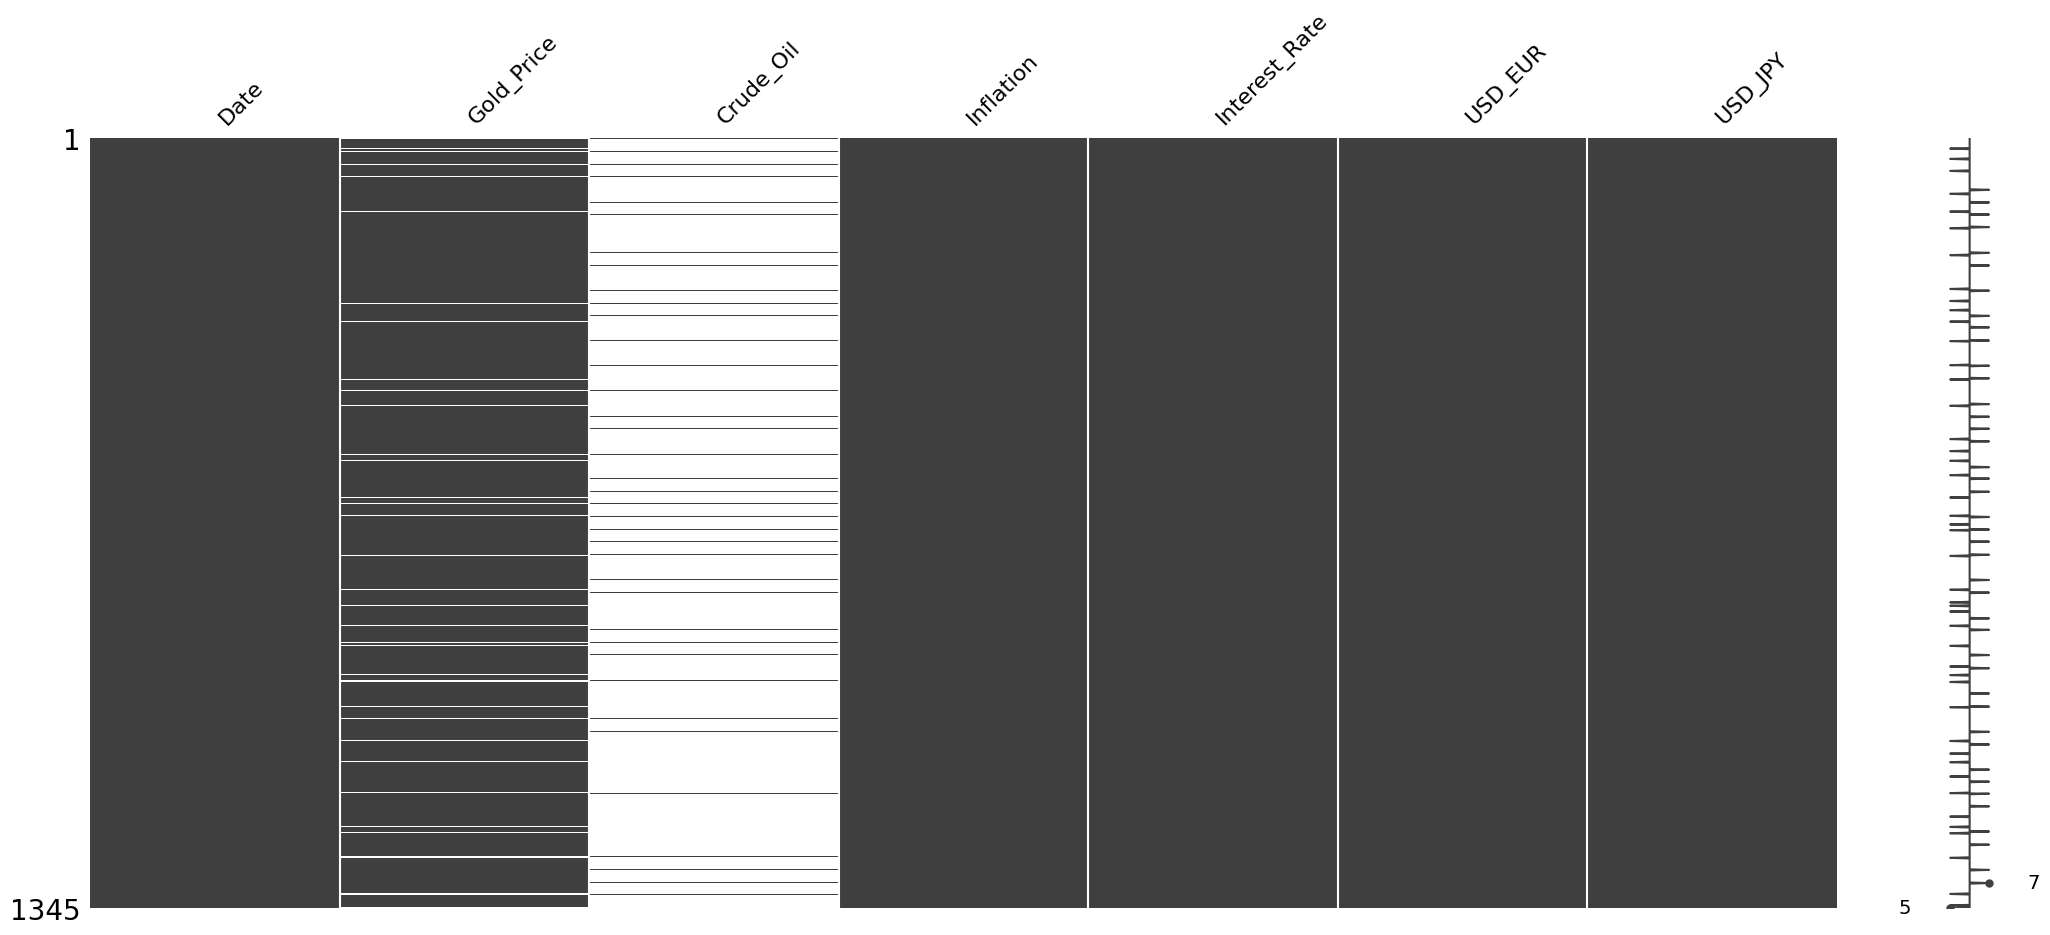

In [17]:
msno.matrix(df)

<Axes: >

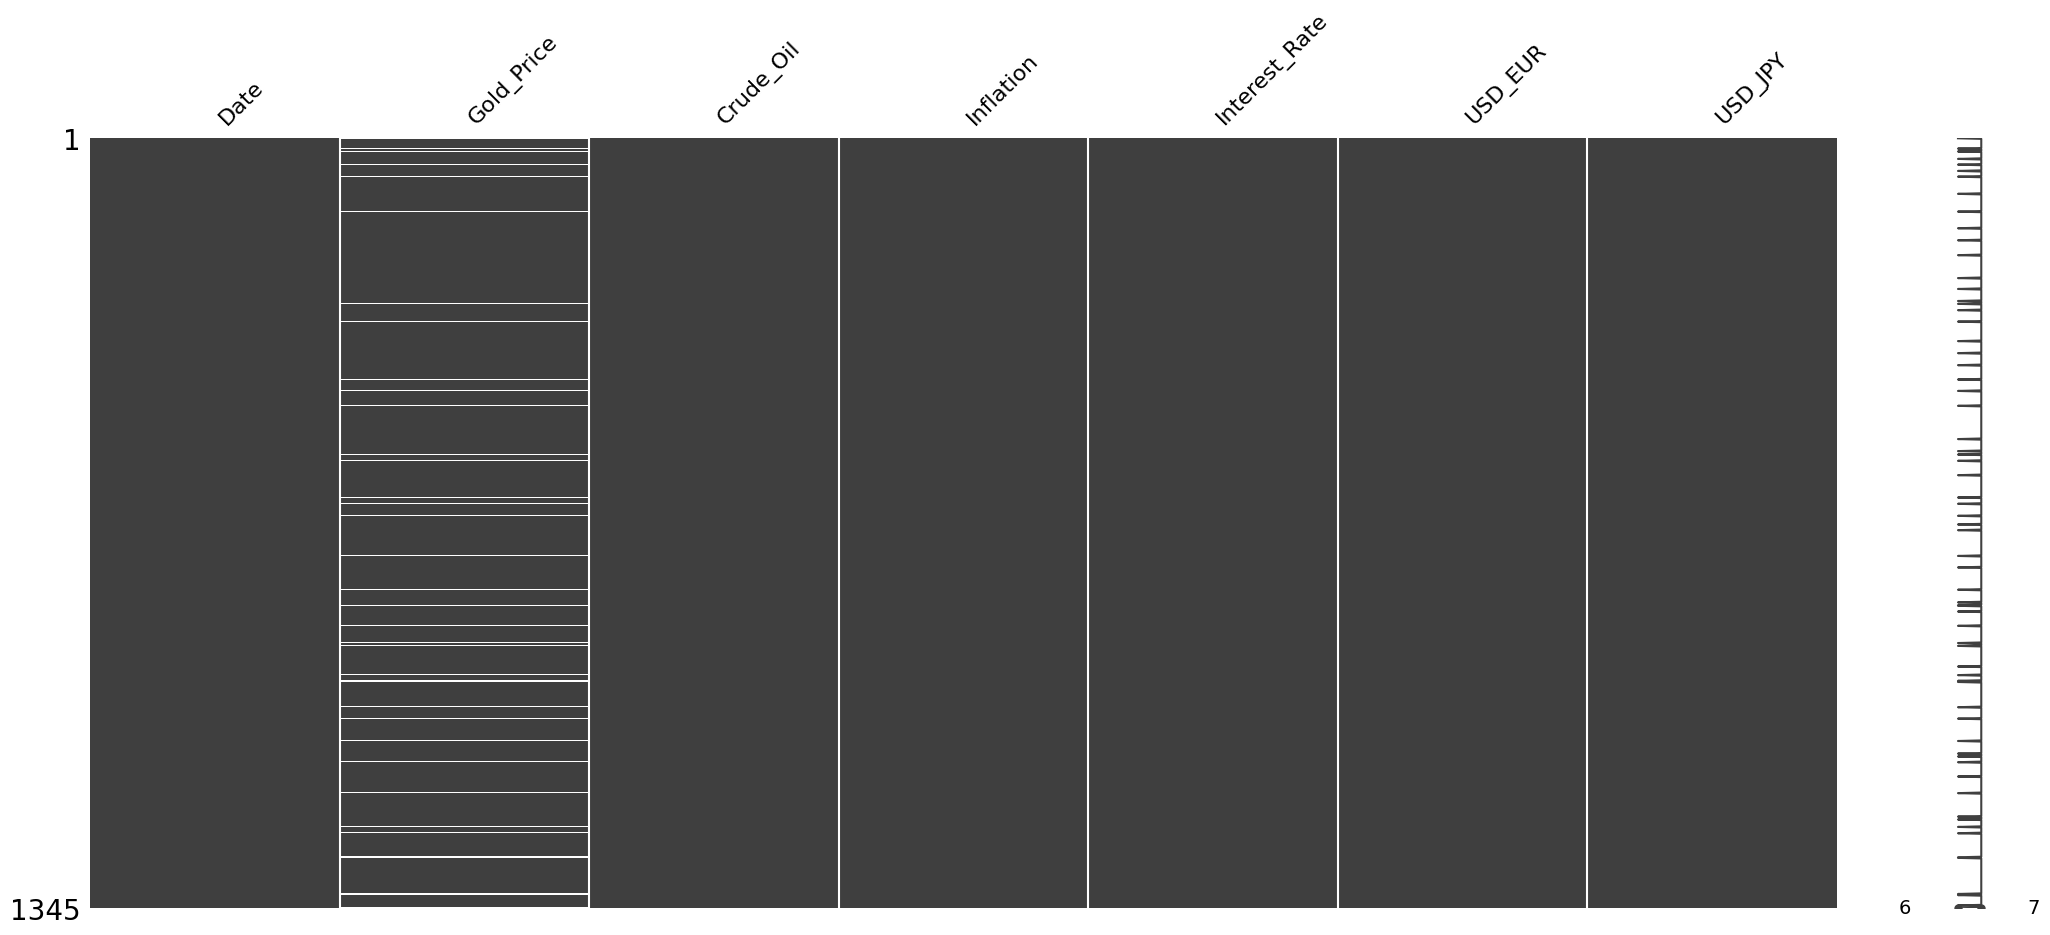

In [18]:
df['Crude_Oil'] = df['Crude_Oil'].ffill()
msno.matrix(df)

Axes(0.125,0.11;0.698618x0.77)
Date             0
Gold_Price       1
Crude_Oil        0
Inflation        0
Interest_Rate    0
USD_EUR          0
USD_JPY          0
dtype: int64


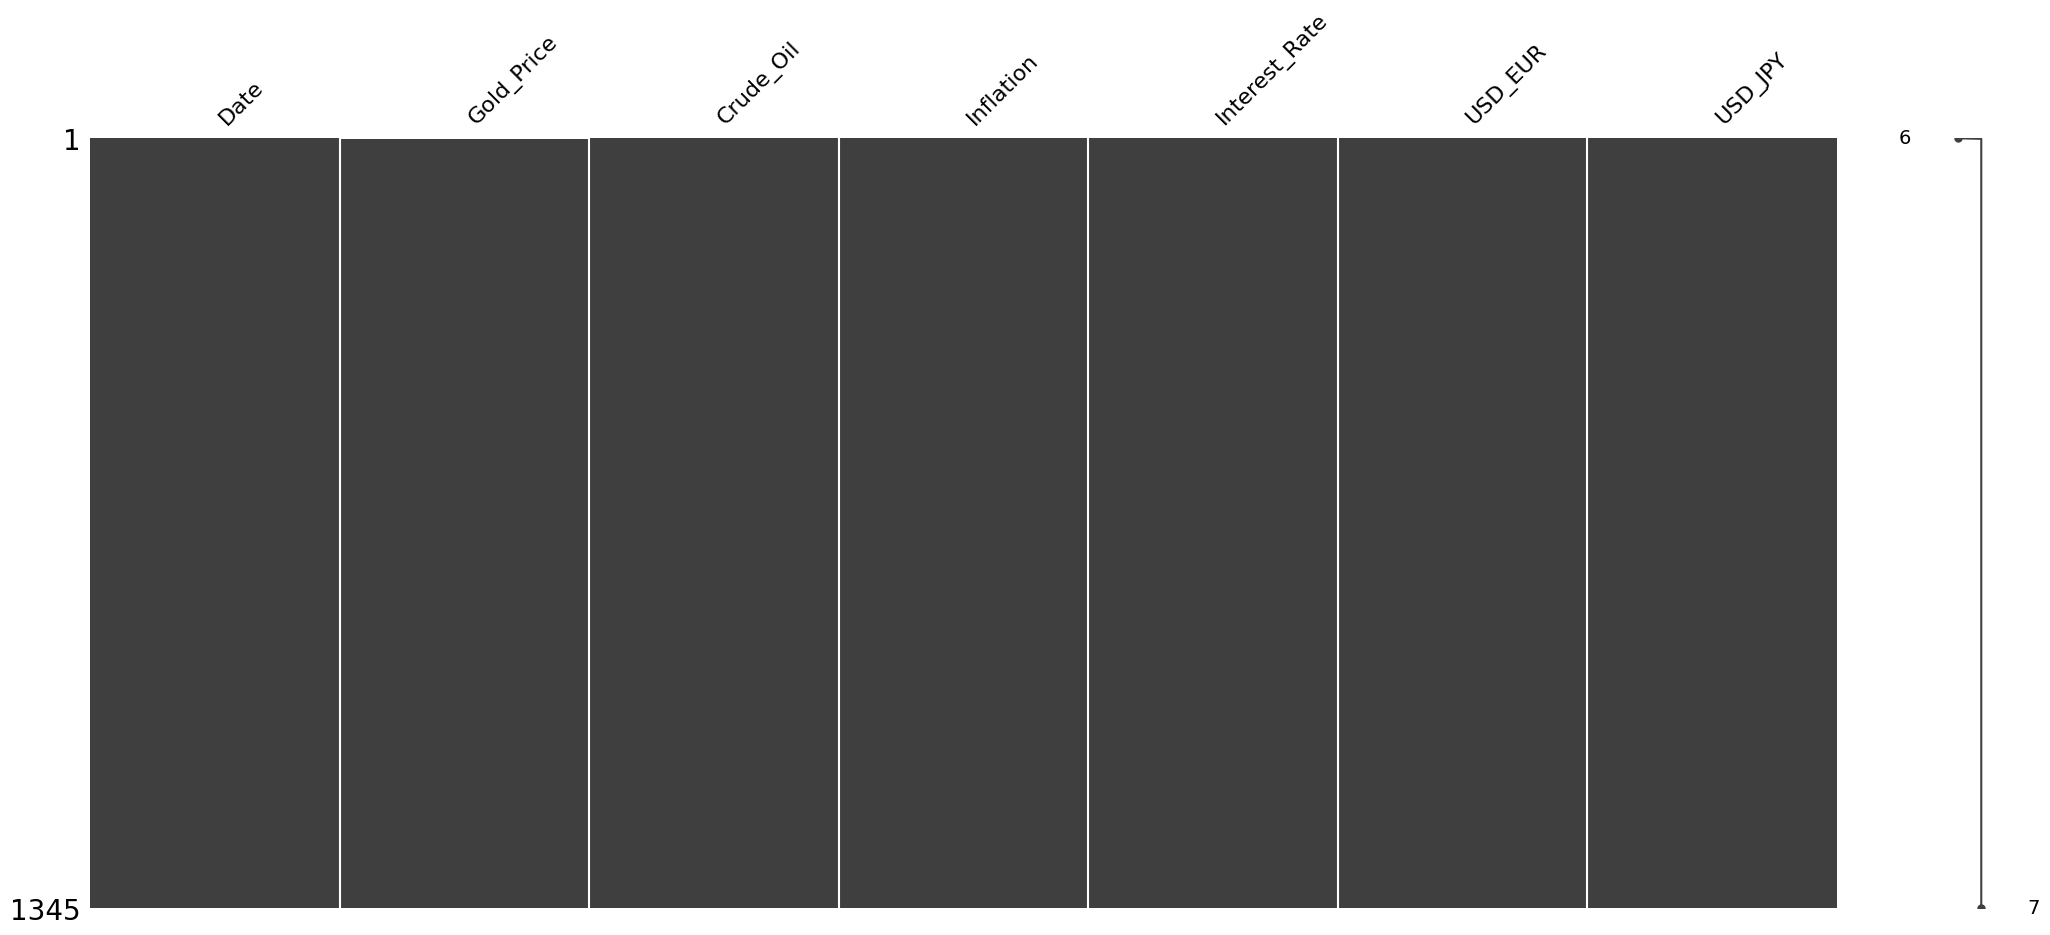

In [19]:
df['Gold_Price'] = df['Gold_Price'].ffill()
print(msno.matrix(df))
print(df.isnull().sum())

In [20]:
df.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,USD_JPY
0,2019-12-01,NaN,67.31,258.63,1.55,1.1075,109.09
1,2019-12-02,137.789993,67.31,258.63,1.55,1.1075,109.09
2,2019-12-03,139.110001,67.31,258.63,1.55,1.1089,108.53
3,2019-12-04,138.919998,67.31,258.63,1.55,1.1076,108.87
4,2019-12-05,139.000000,67.31,258.63,1.55,1.1104,108.69


In [21]:
df = df.dropna()
df.isnull().sum()

Date             0
Gold_Price       0
Crude_Oil        0
Inflation        0
Interest_Rate    0
USD_EUR          0
USD_JPY          0
dtype: int64

In [22]:
df.to_csv(PATH)